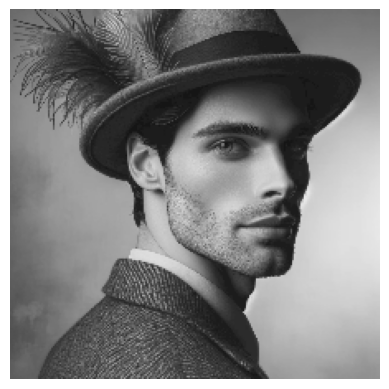

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("like_lenna.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

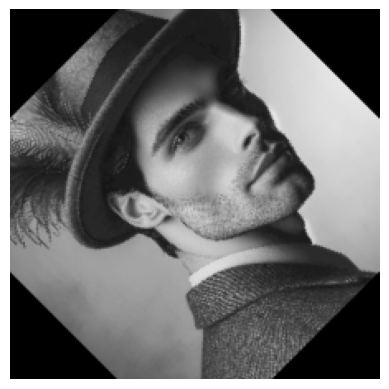

In [2]:
def rotate_image(image, angle, center = None):
    rows, cols,  _ = image.shape
    if center is None:
        center = (cols // 2, rows // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1)
    rotated = cv2.warpAffine(image, M, (cols, rows)) 
    return rotated   

rotate_img = rotate_image(image, 45)

plt.imshow(rotate_img)
plt.axis("off")
plt.show()

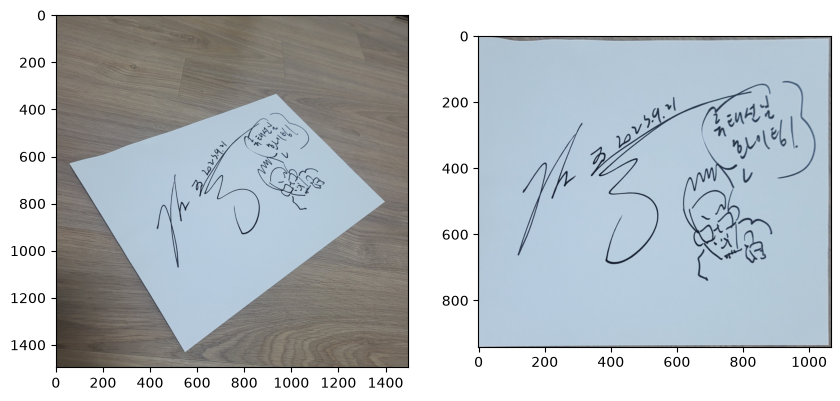

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

new_img = cv2.imread("perspective_test.jpg")

ordered_corners = np.array([[57, 630], [936, 330], [1404, 792], [550, 1431]], dtype = "float32")

ordered_width = int(max(np.linalg.norm(ordered_corners[0] - ordered_corners[1]),
                        np.linalg.norm(ordered_corners[2] - ordered_corners[3])))

ordered_height = int(max(np.linalg.norm(ordered_corners[0]-ordered_corners[3]),
                        np.linalg.norm(ordered_corners[1]-ordered_corners[2])))
# 변환될 꼭짓점 좌표 지정
ordered_rect_corners = np.array([[0, 0], [ordered_width, 0], 
                                 [ordered_width, ordered_height],
                                 [0, ordered_height]], dtype = "float32")


oredered_scan_matrix = cv2.getPerspectiveTransform(ordered_corners, ordered_rect_corners)

ordered_scanned_img = cv2.warpPerspective(new_img, oredered_scan_matrix, (ordered_width, ordered_height))

plt.figure(figsize= (10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2,)
plt.imshow(cv2.cvtColor(ordered_scanned_img, cv2.COLOR_BGR2RGB))
plt.show()

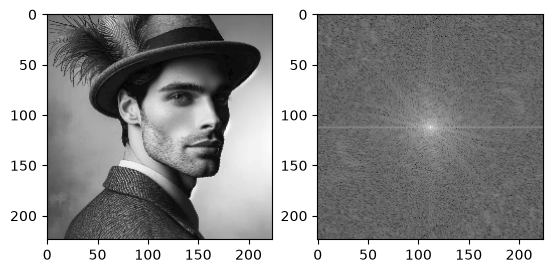

In [4]:
img = cv2.imread("like_lenna.png", cv2.IMREAD_GRAYSCALE)

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_speatrum_original = 20 * np.log(np.abs(fshift))

plt.subplot(121)
plt.imshow(img, cmap= "gray")
plt.subplot(122)
plt.imshow(magnitude_speatrum_original, cmap= "gray")
plt.show()

In [5]:
# 필터링 적용 : 고주파 성분만 제거히는 필터 적용 - 저주파만 통과
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

radius = 30
mask = np.ones((rows, cols), np.uint8)
mask[crow - radius:crow + radius, ccol - radius:ccol + radius] = 0
fshift_filtered = fshift * mask

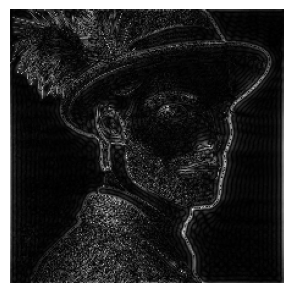

In [6]:
f_shift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_shift)
img_back = np.abs(img_back)

plt.figure(figsize = (12, 12))
plt.subplot(133)
plt.imshow(img_back, cmap = "gray")
plt.axis("off")
plt.show()

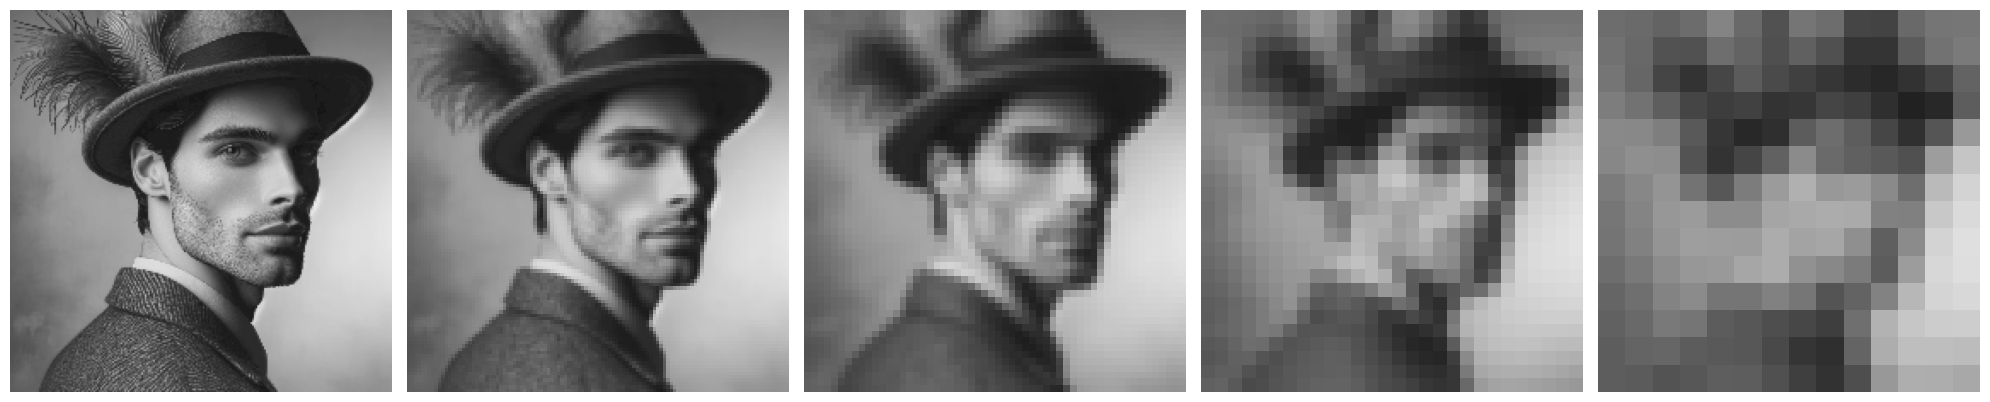

In [7]:
image = cv2.imread("like_lenna.png", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def gussian_pyramid(image, levels):
    pyramid = [image]
    for i in range(levels - 1):
        image = cv2.pyrDown(image)
        pyramid.append(image)
    return pyramid

levels = 5
pyramid = gussian_pyramid(img_rgb, levels)

fig, axes = plt.subplots(1, levels, figsize = (20, 8))
for i, ax in enumerate(axes):
    ax.imshow(pyramid[i])
    ax.axis("off")

plt.tight_layout()
plt.show()


(-0.5, 69.5, 13.5, -0.5)

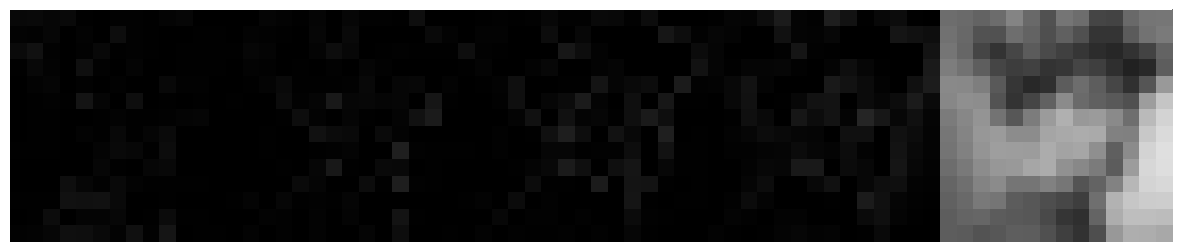

In [8]:
image = cv2.imread("like_lenna.png", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def gussian_pyramid(image, levels):
    pyramid = [image]
    for i in range(levels - 1):
        image = cv2.pyrDown(image)
        pyramid.append(image)
    return pyramid

def laplacian_pyramid(gussian_pyramid):
    laplacian = []
    for i in range(len(gussian_pyramid) - 1):
        next_level = cv2.pyrUp(gussian_pyramid[i + 1])
        if next_level.shape[0] > gussian_pyramid[i].shape[0]:
            next_level = next_level[:-1, :, :]

        if next_level.shape[1] > gussian_pyramid[i].shape[1]:
            next_level = next_level[:, : -1, :]

        lap = cv2.subtract(gussian_pyramid[i], next_level)
        laplacian.append(lap)

    laplacian.append(gussian_pyramid[-1])

    return laplacian

levels = 5

g_pyramid = gussian_pyramid(img_rgb, levels)
l_pyramid = laplacian_pyramid(g_pyramid)

min_height = min([img.shape[0] for img in l_pyramid])
concat_lap_hor = cv2.resize(
    l_pyramid[0],(
        int(l_pyramid[0].shape[1] * min_height / l_pyramid[0].shape[0]),
        min_height
    )
)
fig, ax = plt.subplots(figsize = (15, 6))

for idx, img in enumerate(l_pyramid[1:], start= 1):
    resized_img = cv2.resize(
        img, (
            int(img.shape[1] * min_height / img.shape[0]),
            min_height
        )
    )
    concat_lap_hor = cv2.hconcat([concat_lap_hor, resized_img])

ax.imshow(concat_lap_hor, cmap= "gray")
ax.axis("off")


(-0.5, 223.5, 223.5, -0.5)

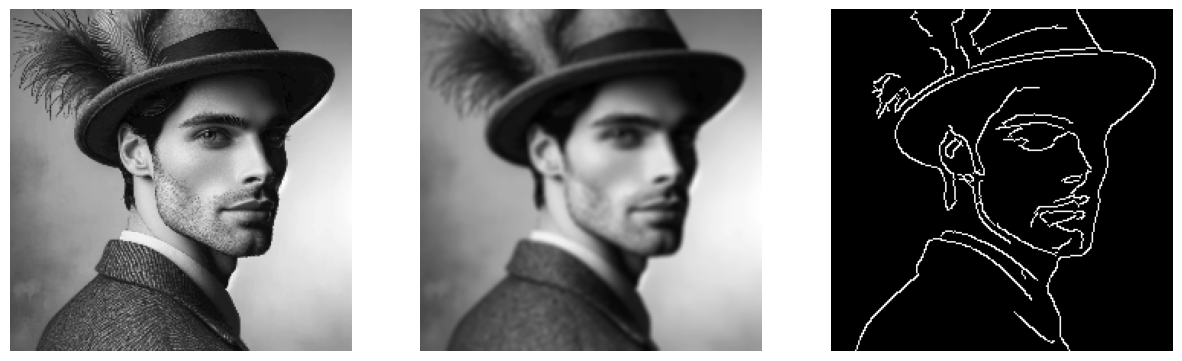

In [9]:
import cv2
import matplotlib.pylab as plt

img = cv2.imread("like_lenna.png", cv2.IMREAD_GRAYSCALE)
blurred_img = cv2.GaussianBlur(img, (5, 5), 1.4)

canny_edge = cv2.Canny(blurred_img, threshold1= 50, threshold2= 150)

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

axes[0].imshow(img, cmap = "gray")
axes[0].axis("off")
axes[1].imshow(blurred_img, cmap = "gray")
axes[1].axis("off")
axes[2].imshow(canny_edge, cmap = "gray")
axes[2].axis("off")

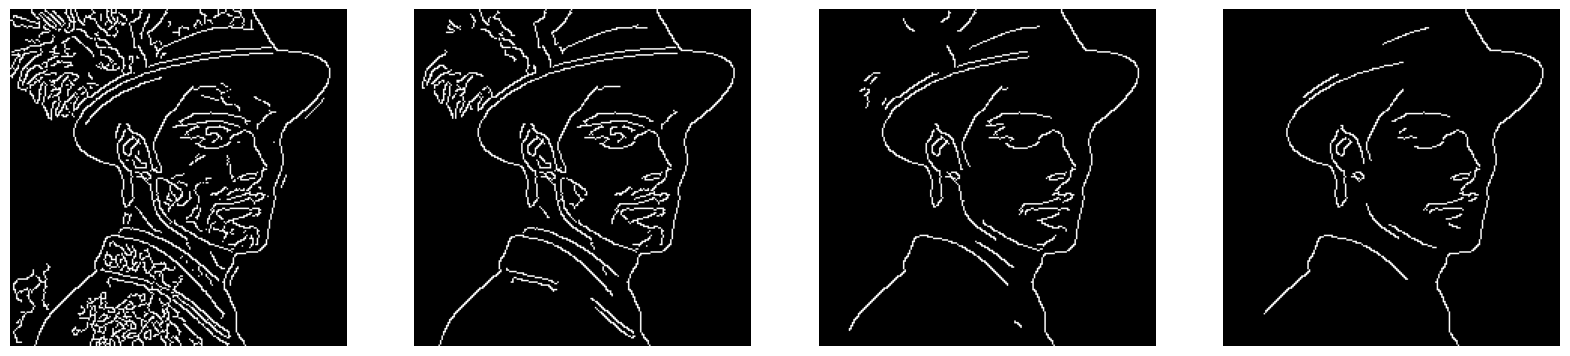

In [10]:
thresholds = [(10, 50), (50, 100), (100, 150), (150, 200)]
canny_res = []

for threshold1, threshold2 in thresholds:
    canny_img = cv2.Canny(blurred_img, threshold1= threshold1, 
                          threshold2= threshold2)
    canny_res.append(canny_img)

fig, axes = plt.subplots(1, len(thresholds), figsize = (20, 5))

for i, ax in enumerate(axes):
    ax.imshow(canny_res[i], cmap='gray')
    ax.axis("off")


In [11]:
img = cv2.imread("like_lenna.png", cv2.IMREAD_COLOR)

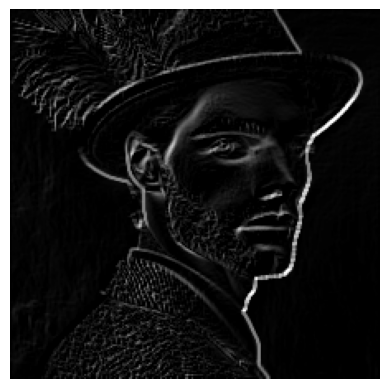

In [12]:
kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

gx = cv2.filter2D(img, -1, kx)
gy = cv2.filter2D(img, -1, ky)

prewitt_res = cv2.addWeighted(gx, 0.5, gy, 0.5, 0)

plt.imshow(prewitt_res, cmap= "gray")
plt.axis("off")
plt.show()

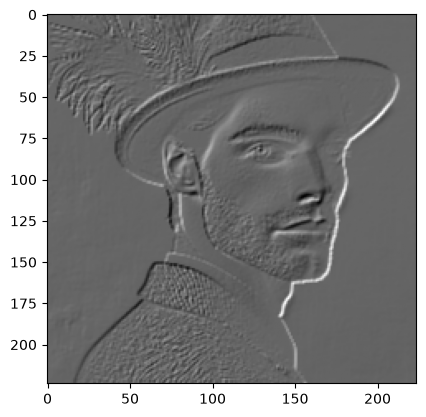

In [16]:
img = cv2.imread('like_lenna.png', cv2.IMREAD_GRAYSCALE)

gx_sobel = cv2.Sobel(img, cv2.CV_64F, 1, 0,ksize =3)
gy_sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1,ksize =3)

sobel_res = cv2.addWeighted(gx_sobel, 0.5, gy_sobel, 0.5,0)

plt.imshow(sobel_res, cmap = 'gray')
plt.show()